2) Produrre più film porta a un successo maggiore?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib.ticker as ticker

df = pd.read_pickle('Film.pickle')

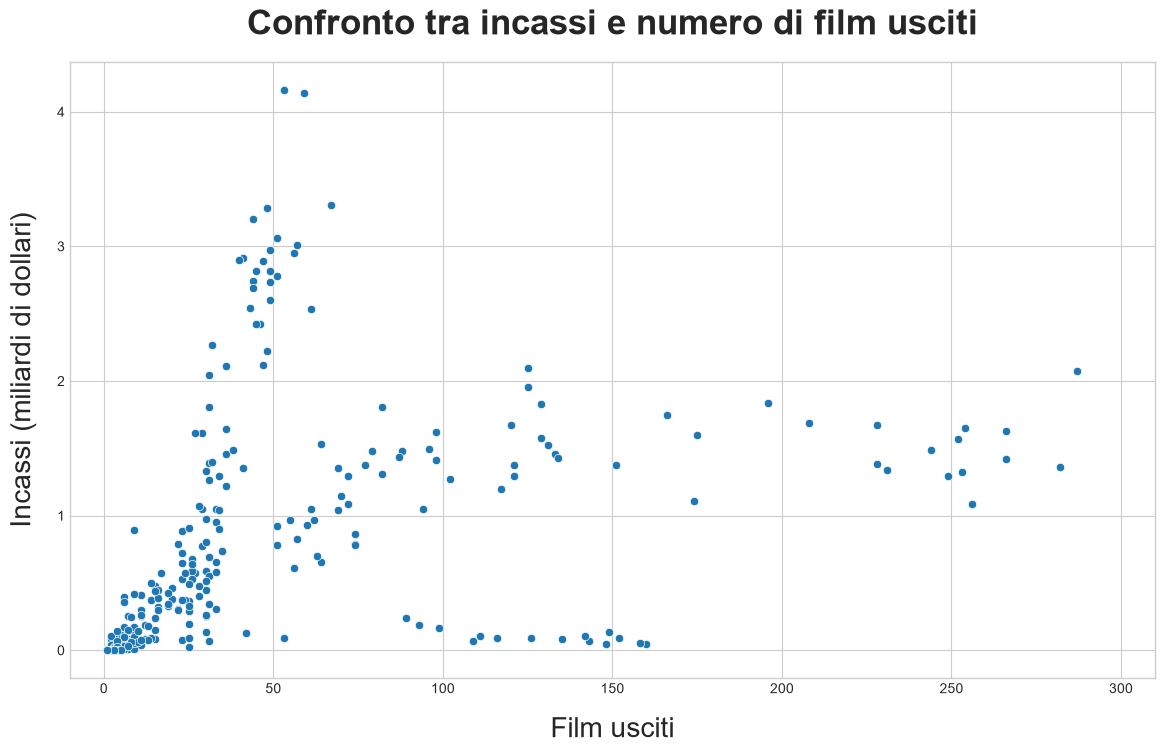

In [5]:
# Inizializzazione dello stile
plt.style.use('seaborn-v0_8-whitegrid')

plt.figure(figsize=(14, 8))
ax = sns.scatterplot(data=df, x='film_usciti', y='lordo', marker='o')

# Titoli degli assi
plt.title('Confronto tra incassi e numero di film usciti', fontsize=25, fontweight='bold', pad=20)
plt.xlabel('Film usciti', fontsize=20, fontweight='normal', labelpad=15)
plt.ylabel('Incassi (miliardi di dollari)', fontsize=20, fontweight='normal', labelpad=15)
ax.set_xlim(-10, 310)

# Formatto in modo che mostri come scala i miliardi
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'{x * 1e-9:.0f}'))

# Salvataggio
plt.savefig("figures/2_1.png", bbox_inches='tight')
plt.savefig("figures/2_1.svg", bbox_inches='tight')

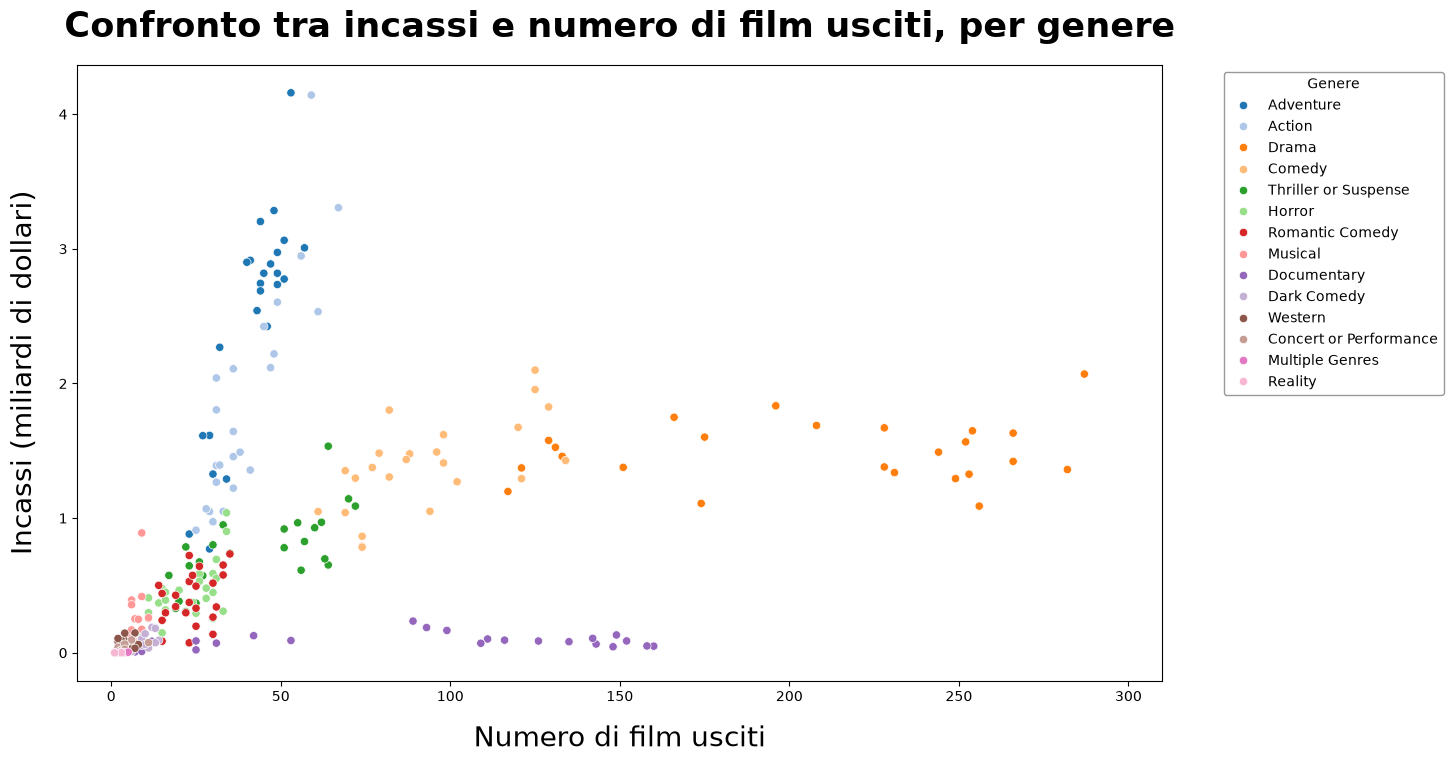

In [4]:
# Andando più a fondo... (da mettere in presentazione)

plt.figure(figsize=(14, 8))
ax = sns.scatterplot(data=df, x='film_usciti', y='lordo', hue='genere', marker='o', palette='tab20')

# Titoli degli assi
plt.title('Confronto tra incassi e numero di film usciti, per genere', fontsize=25, fontweight='bold', pad=20)
plt.xlabel('Numero di film usciti', fontsize=20, fontweight='normal', labelpad=15)
plt.ylabel('Incassi (miliardi di dollari)', fontsize=20, fontweight='normal', labelpad=15)
ax.set_xlim(-10, 310)

# Formatto in modo che mostri come scala i miliardi
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'{x * 1e-9:.0f}'))

# Legenda
plt.legend(title='Genere', frameon=True, facecolor='white', edgecolor='gray', bbox_to_anchor=(1.05, 1), loc='upper left')

# Salvataggio
plt.savefig("figures/2_2.png", bbox_inches='tight')
plt.savefig("figures/2_2.svg", bbox_inches='tight')

# Per riportare la stessa palette nel terzo grafico
generi = df['genere'].unique()
colori_tab20 = sns.color_palette('tab20', len(generi))
mappa_colori = dict(zip(generi, colori_tab20))

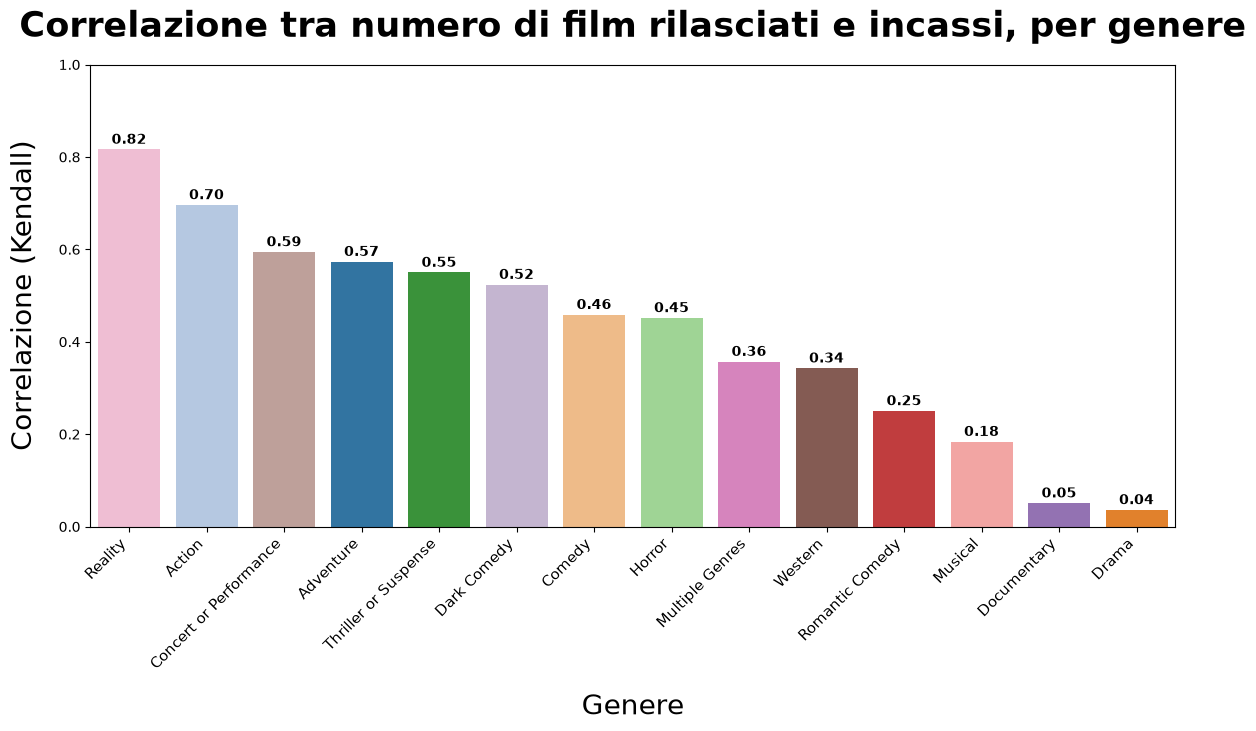

In [6]:
# Grafico a barre con correlazione, y --> correlazione, x --> generi, ordinati dal più grande al più piccolo
# Ricordati di dire che i valori sono poco significativi per le categorie che non hanno tutti gli anni
#####################################################################qua

# Calcolo della correlazione
correlazioni = {}
for genere in df['genere'].unique():
    df_genere = df[df['genere'] == genere]
    corr = df_genere[['film_usciti', 'lordo']].corr(method='kendall')
    # me li salva in una matrice 2x2, prendo solo una volta la correlazione
    correlazioni[genere] = corr.iloc[0, 1]

#correlazioni

# creo un df che contenga i dati e li ordino dal più grande al più piccolo
df_corr = pd.DataFrame(list(correlazioni.items()), columns=['genere', 'correlazione']).dropna()
df_corr = df_corr.sort_values(by='correlazione', ascending=False)
#df_corr

plt.figure(figsize=(14, 6))
ax = sns.barplot(data=df_corr, x='genere', y='correlazione', hue='genere', palette=mappa_colori) # uso gli stessi abbinamenti colore codice di prima

# Assi
plt.title('Correlazione tra numero di film rilasciati e incassi, per genere', fontsize=25, fontweight='bold', pad=20)
plt.xlabel('Genere', fontsize=20, fontweight='normal', labelpad=15)
plt.ylabel('Correlazione (Kendall)', fontsize=20, fontweight='normal', labelpad=15)
ax.set_ylim(0, 1)

# Ruoto le label dell'asse x
plt.xticks(rotation=45, ha='right', fontsize=11)

# Numeri sulle barre
for i, corr in enumerate(df_corr['correlazione']):
    plt.text(i, corr+0.02, f'{corr:.2f}', ha='center', va='center', fontsize=10, fontweight='bold')

# Salvataggio
plt.savefig("figures/2_3.png", bbox_inches='tight')
plt.savefig("figures/2_3.svg", bbox_inches='tight')